In [29]:
import numpy as np
import cvxpy as cp
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [30]:
"""
# ============================================================
# Predicate-Regularized SVM (Binary, Linear Kernel)
# If Phi=None or tau=0 → reduces to standard SVM
# ============================================================
class PredicateSVM:
    def __init__(self, C=1.0, tau=0.0):
        self.C = C
        self.tau = tau
        self.alpha = None
        self.w = None
        self.b = None

    def fit(self, X, y, Phi=None):

        n = X.shape[0]

        K = X @ X.T
        Y = np.outer(y, y)
        Q = Y * K

        if Phi is not None and self.tau > 0:
            P = (Phi @ Phi.T) / Phi.shape[1]
            Q = Q + self.tau * P

        Q = (Q + Q.T) / 2  # ensure symmetry

        # ---- Critical fix ----
        Q = cp.psd_wrap(Q)

        alpha = cp.Variable(n)

        objective = cp.Minimize(
            0.5 * cp.quad_form(alpha, Q) - cp.sum(alpha)
        )

        constraints = [
            alpha >= 0,
            alpha <= self.C,
            y @ alpha == 0
        ]

        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.OSQP)

        self.alpha = alpha.value

        self.w = ((self.alpha * y)[:, None] * X).sum(axis=0)

        support = self.alpha > 1e-5
        self.b = np.mean(y[support] - X[support] @ self.w)

        return self



    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return np.sign(self.decision_function(X))


# ============================================================
# Vapnik Exact Predicate Builder (Section 7.1)
# φ(x)=1, φ(x)=x, φ(x)=xx^T
# ============================================================

def build_vapnik_predicates(X):
    n, d = X.shape
    predicates = []

    # 1) phi(x)=1
    predicates.append(np.ones(n))

    # 2) phi(x)=x
    for j in range(d):
        predicates.append(X[:, j])

    # 3) phi(x)=xx^T
    for j in range(d):
        for k in range(j, d):
            predicates.append(X[:, j] * X[:, k])

    Phi = np.column_stack(predicates)

    # Normalize columns (important for stability)
    Phi = Phi / np.linalg.norm(Phi, axis=0, keepdims=True)

    return Phi
"""


'\n# ============================================================\n# Predicate-Regularized SVM (Binary, Linear Kernel)\n# If Phi=None or tau=0 → reduces to standard SVM\n# ============================================================\nclass PredicateSVM:\n    def __init__(self, C=1.0, tau=0.0):\n        self.C = C\n        self.tau = tau\n        self.alpha = None\n        self.w = None\n        self.b = None\n\n    def fit(self, X, y, Phi=None):\n\n        n = X.shape[0]\n\n        K = X @ X.T\n        Y = np.outer(y, y)\n        Q = Y * K\n\n        if Phi is not None and self.tau > 0:\n            P = (Phi @ Phi.T) / Phi.shape[1]\n            Q = Q + self.tau * P\n\n        Q = (Q + Q.T) / 2  # ensure symmetry\n\n        # ---- Critical fix ----\n        Q = cp.psd_wrap(Q)\n\n        alpha = cp.Variable(n)\n\n        objective = cp.Minimize(\n            0.5 * cp.quad_form(alpha, Q) - cp.sum(alpha)\n        )\n\n        constraints = [\n            alpha >= 0,\n            alpha <= s

In [31]:
# ============================================================
# Predicate-Regularized SVM (Binary, Linear or RBF Kernel)
# If Phi=None or tau=0 → reduces to standard SVM
# ============================================================

import numpy as np
import cvxpy as cp


class PredicateSVM:
    def __init__(self, C=1.0, tau=0.0, kernel="rbf", gamma=1.0):
        """
        C       : SVM regularization parameter
        tau     : predicate strength (tau=0 → standard SVM)
        kernel  : "linear" or "rbf"
        gamma   : RBF parameter
        """
        self.C = C
        self.tau = tau
        self.kernel = kernel
        self.gamma = gamma

        self.alpha = None
        self.b = None
        self.X_train = None
        self.y_train = None

    # --------------------------------------------------------
    # Kernel computation
    # --------------------------------------------------------
    def _compute_kernel(self, X1, X2):
        if self.kernel == "linear":
            return X1 @ X2.T

        elif self.kernel == "rbf":
            X1_sq = np.sum(X1**2, axis=1, keepdims=True)
            X2_sq = np.sum(X2**2, axis=1, keepdims=True)
            sq_dists = X1_sq - 2 * X1 @ X2.T + X2_sq.T
            return np.exp(-self.gamma * sq_dists)

        else:
            raise ValueError("Unsupported kernel.")

    # --------------------------------------------------------
    # Fit
    # --------------------------------------------------------
    def fit(self, X, y, Phi=None):

        self.X_train = X
        self.y_train = y

        n = X.shape[0]

        K = self._compute_kernel(X, X)
        Y = np.outer(y, y)
        Q = Y * K

        # Add predicate term if provided
        if Phi is not None and self.tau > 0:
            P = (Phi @ Phi.T) / Phi.shape[1]
            Q = Q + self.tau * P

        Q = (Q + Q.T) / 2
        Q = cp.psd_wrap(Q)

        alpha = cp.Variable(n)

        objective = cp.Minimize(
            0.5 * cp.quad_form(alpha, Q) - cp.sum(alpha)
        )

        constraints = [
            alpha >= 0,
            alpha <= self.C,
            y @ alpha == 0
        ]

        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.OSQP)

        self.alpha = alpha.value

        # Compute bias using support vectors
        support = self.alpha > 1e-5
        K_support = self._compute_kernel(X[support], X)
        self.b = np.mean(
            y[support] - (K_support @ (self.alpha * y))
        )

        return self

    # --------------------------------------------------------
    # Decision function
    # --------------------------------------------------------
    def decision_function(self, X_new):
        K_new = self._compute_kernel(X_new, self.X_train)
        return K_new @ (self.alpha * self.y_train) + self.b

    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------
    def predict(self, X_new):
        return np.sign(self.decision_function(X_new))


# ============================================================
# Vapnik Exact Predicate Builder (Section 7.1)
# φ(x)=1, φ(x)=x, φ(x)=xx^T
# ============================================================

def build_vapnik_predicates(X):

    n, d = X.shape
    predicates = []

    # 1) phi(x)=1
    predicates.append(np.ones(n))

    # 2) phi(x)=x
    for j in range(d):
        predicates.append(X[:, j])

    # 3) phi(x)=xx^T
    for j in range(d):
        for k in range(j, d):
            predicates.append(X[:, j] * X[:, k])

    Phi = np.column_stack(predicates)

    # Normalize columns for numerical stability
    Phi = Phi / (np.linalg.norm(Phi, axis=0, keepdims=True) + 1e-12)

    return Phi


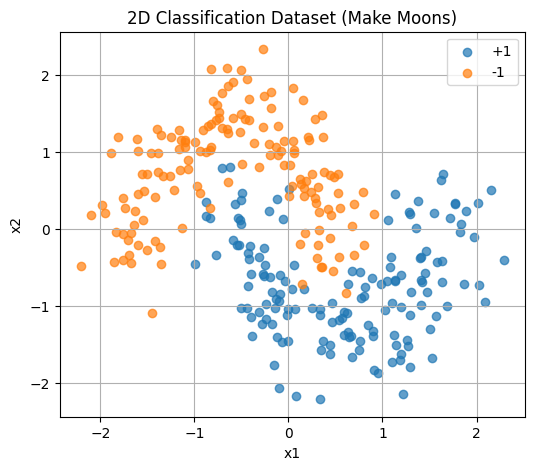

In [32]:
# ============================================================
# Load and Plot 2D Classification Dataset
# ============================================================
# Generate dataset
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# Convert labels from {0,1} to {-1,+1}
y = 2*y - 1

# Optional: scale for better SVM behavior
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Plot dataset
plt.figure(figsize=(6,5))
plt.scatter(X[y==1, 0], X[y==1, 1], label="+1", alpha=0.7)
plt.scatter(X[y==-1, 0], X[y==-1, 1], label="-1", alpha=0.7)
plt.title("2D Classification Dataset (Make Moons)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()


Standard SVM accuracy: 0.9733333333333334
Predicate SVM accuracy: 0.9666666666666667


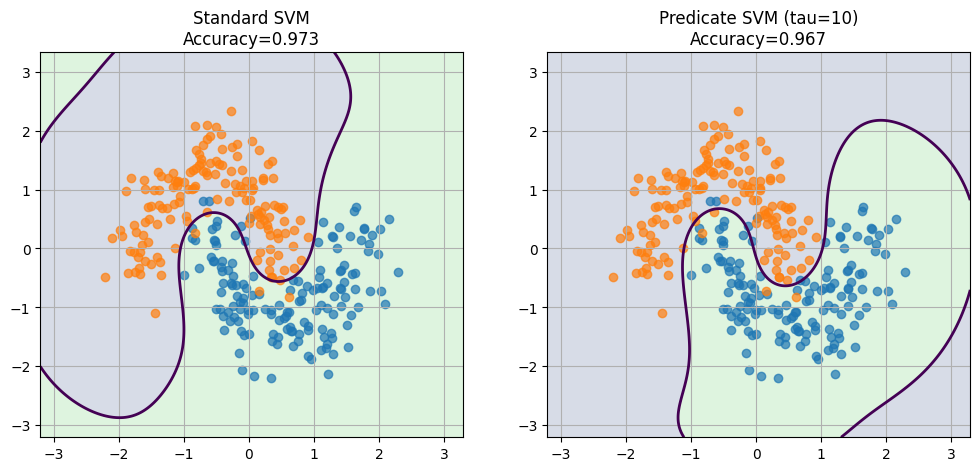

In [39]:
# ============================================================
# Train Standard SVM vs Predicate-SVM and Plot Results
# ============================================================
# ---- Build predicates ----
Phi = build_vapnik_predicates(X)

# ---- Train standard SVM ----
svm_standard = PredicateSVM(C=1.0, tau=0.0)
svm_standard.fit(X, y)

# ---- Train predicate SVM ----
svm_pred = PredicateSVM(C=1.0, tau=10.0)
svm_pred.fit(X, y, Phi=Phi)

# ---- Accuracy ----
y_pred_standard = svm_standard.predict(X)
y_pred_pred = svm_pred.predict(X)

acc_standard = accuracy_score(y, y_pred_standard)
acc_pred = accuracy_score(y, y_pred_pred)

print("Standard SVM accuracy:", acc_standard)
print("Predicate SVM accuracy:", acc_pred)

# ---- Create mesh grid for decision boundary ----
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]

# Decision functions
Z_standard = svm_standard.decision_function(grid).reshape(xx.shape)
Z_pred = svm_pred.decision_function(grid).reshape(xx.shape)

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Standard SVM
axes[0].contourf(xx, yy, Z_standard > 0, alpha=0.2)
axes[0].contour(xx, yy, Z_standard, levels=[0], linewidths=2)
axes[0].scatter(X[y==1,0], X[y==1,1], alpha=0.7)
axes[0].scatter(X[y==-1,0], X[y==-1,1], alpha=0.7)
axes[0].set_title(f"Standard SVM\nAccuracy={acc_standard:.3f}")
axes[0].grid(True)

# Predicate SVM
axes[1].contourf(xx, yy, Z_pred > 0, alpha=0.2)
axes[1].contour(xx, yy, Z_pred, levels=[0], linewidths=2)
axes[1].scatter(X[y==1,0], X[y==1,1], alpha=0.7)
axes[1].scatter(X[y==-1,0], X[y==-1,1], alpha=0.7)
axes[1].set_title(f"Predicate SVM (tau=10)\nAccuracy={acc_pred:.3f}")
axes[1].grid(True)

plt.show()


In [41]:
# ============================================================
# Predicate-Regularized Neural Network (Binary Classification)
# If tau=0 → standard NN
# ============================================================
# ------------------------------------------------------------
# Simple MLP
# ------------------------------------------------------------
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze()


# ------------------------------------------------------------
# Training function
# ------------------------------------------------------------
def train_predicate_nn(X, y, Phi=None,
                       tau=0.0,
                       epochs=1000,
                       lr=1e-3,
                       hidden_dim=32):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    y_t = torch.tensor(y, dtype=torch.float32).to(device)

    model = SimpleNN(X.shape[1], hidden_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    if Phi is not None:
        Phi_t = torch.tensor(Phi, dtype=torch.float32).to(device)

    for _ in range(epochs):

        optimizer.zero_grad()

        logits = model(X_t)
        loss_task = criterion(logits, (y_t + 1)/2)  # convert {-1,+1} to {0,1}

        if Phi is not None and tau > 0:
            preds = torch.sigmoid(logits)

            # Compute predicate violation
            pred_stat = Phi_t.T @ preds
            true_stat = Phi_t.T @ ((y_t + 1)/2)

            loss_pred = torch.mean((pred_stat - true_stat) ** 2)

            loss = loss_task + tau * loss_pred
        else:
            loss = loss_task

        loss.backward()
        optimizer.step()

    return model


# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------
def evaluate_nn(model, X, y):
    device = next(model.parameters()).device
    X_t = torch.tensor(X, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(X_t)
        preds = torch.sign(logits).cpu().numpy()

    acc = (preds == y).mean()
    return acc


Standard NN accuracy: 0.9666666666666667
Predicate NN accuracy: 0.9666666666666667


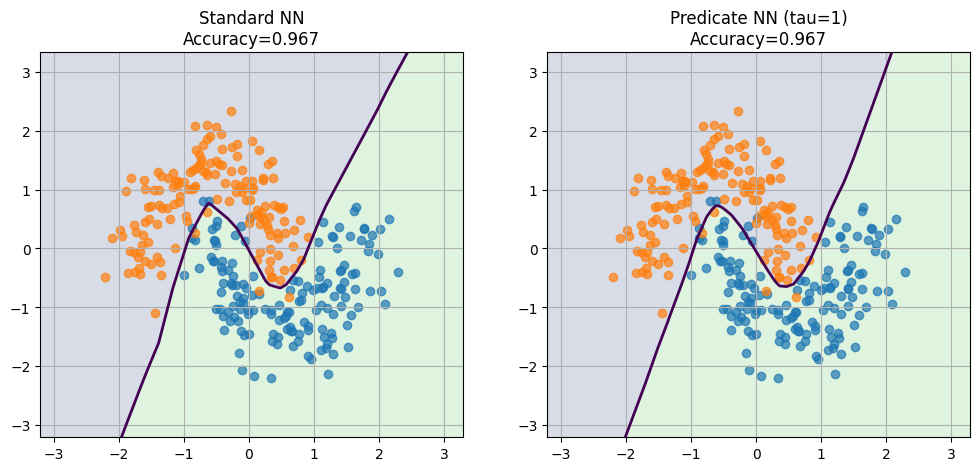

In [44]:
# ============================================================
# Train Standard NN vs Predicate-NN and Plot Results
# ============================================================
# ---- Build predicates ----
Phi = build_vapnik_predicates(X)

# ---- Train models ----
model_std = train_predicate_nn(X, y, tau=0.0, epochs=2000, lr=1e-3)
model_pred = train_predicate_nn(X, y, Phi=Phi, tau=0.01, epochs=2000, lr=1e-3)

# ---- Accuracy ----
acc_std = evaluate_nn(model_std, X, y)
acc_pred = evaluate_nn(model_pred, X, y)

print("Standard NN accuracy:", acc_std)
print("Predicate NN accuracy:", acc_pred)

# ---- Decision boundary grid ----
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]

device = next(model_std.parameters()).device
grid_t = torch.tensor(grid, dtype=torch.float32).to(device)

with torch.no_grad():
    Z_std = model_std(grid_t).cpu().numpy().reshape(xx.shape)
    Z_pred = model_pred(grid_t).cpu().numpy().reshape(xx.shape)

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Standard NN
axes[0].contourf(xx, yy, Z_std > 0, alpha=0.2)
axes[0].contour(xx, yy, Z_std, levels=[0], linewidths=2)
axes[0].scatter(X[y==1,0], X[y==1,1], alpha=0.7)
axes[0].scatter(X[y==-1,0], X[y==-1,1], alpha=0.7)
axes[0].set_title(f"Standard NN\nAccuracy={acc_std:.3f}")
axes[0].grid(True)

# Predicate NN
axes[1].contourf(xx, yy, Z_pred > 0, alpha=0.2)
axes[1].contour(xx, yy, Z_pred, levels=[0], linewidths=2)
axes[1].scatter(X[y==1,0], X[y==1,1], alpha=0.7)
axes[1].scatter(X[y==-1,0], X[y==-1,1], alpha=0.7)
axes[1].set_title(f"Predicate NN (tau=1)\nAccuracy={acc_pred:.3f}")
axes[1].grid(True)

plt.show()
